In [137]:
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools

In [2]:
N = 5

# lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
lista = np.array([n+1 for n in range(N**2)])
matriz_lista = lista.reshape(N,N)
matriz_lista

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [3]:
def matriz_aumentada(m):
    temp_list = []; N = len(m)
    temp_list.append(np.concatenate([[m[N-1,N-1]], m[N-1], [m[N-1,0]]]))
    
    for i in range(N):
        temp_list.append(np.concatenate([[m[i,N-1]], m[i], [m[i,0]]]))
    
    temp_list.append(np.concatenate([[m[0,N-1]], m[0], [m[0,0]]]))
    return np.matrix(temp_list)
        
matriz_aumentada(matriz_lista)

matrix([[25, 21, 22, 23, 24, 25, 21],
        [ 5,  1,  2,  3,  4,  5,  1],
        [10,  6,  7,  8,  9, 10,  6],
        [15, 11, 12, 13, 14, 15, 11],
        [20, 16, 17, 18, 19, 20, 16],
        [25, 21, 22, 23, 24, 25, 21],
        [ 5,  1,  2,  3,  4,  5,  1]])

In [4]:
filtro1 = np.matrix([[0, 1, 0],
                    [1, 0, 1],
                    [0, 1, 0]])

filtro2 = np.matrix([[1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3],
                    [1, 0, 1],
                    [1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3]])

def primeros_vecinos(m, i, j, filtro=filtro1):
    M_a = matriz_aumentada(m) 
    A = (M_a[i-1:i+2, j-1:j+2])
    
    return np.multiply(A,filtro)

primeros_vecinos(matriz_lista, 1, 1), primeros_vecinos(matriz_lista, 1, 1, filtro=filtro2)

(matrix([[ 0, 21,  0],
         [ 5,  0,  2],
         [ 0,  6,  0]]),
 matrix([[ 8.83883476, 21.        ,  7.77817459],
         [ 5.        ,  0.        ,  2.        ],
         [ 3.53553391,  6.        ,  2.47487373]]))

In [5]:
J = 0.5;
def energia(m, i, j, filtro=filtro1):
    vecinos = primeros_vecinos(m, i, j, filtro=filtro)
    E = vecinos * m[i-1,j-1]
    return -J * np.sum(E)

energia(matriz_lista, 1, 1), energia(matriz_lista, 1, 1, filtro=filtro2)

(-17.0, -28.31370849898476)

### Prueba de energía

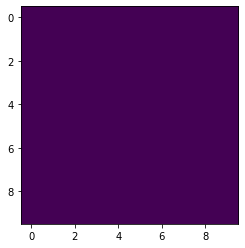

In [142]:
n1 = 10

# lista = np.array([random.choice([-1, 1]) for n in range(n1**2)])
lista = np.array([1 for n in range(n1**2)])
red = lista.reshape(n1,n1)

plt.imshow(red);

In [84]:
def energia_total(m, filtro=filtro1):
    s = 0; N = len(m)
    for i, j in itertools.product(range(1,N+1), range(1,N+1)):
        s = energia(m, i, j, filtro=filtro) + s
    return s
        
energia_total(red), energia_total(red, filtro=filtro2)

(-200.0, -270.71067811865515)

In [8]:
def energia_p(m, filtro=filtro1):
    return energia_total(m, filtro=filtro1)/len(m)**2
        
energia_p(red), energia_p(red, filtro=filtro2)

(-2.0, -2.0)

### Magnetización promedio

In [10]:
def mag_p(m):
    return np.sum(m)/len(m)**2

mag_p(red)

1.0

### Metropolis-Montecarlo

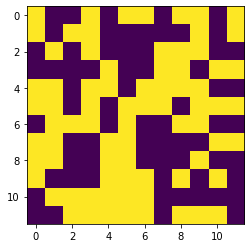

In [260]:
n1 = 12
lista = np.array([1 for n in range(n1**2)])
red = lista.reshape(n1,n1)
red, energia_total(red, filtro=filtro2)

lista = np.array([random.choice([-1, 1]) for n in range(n1**2)])
red_a = lista.reshape(n1,n1)

plt.imshow(red)
plt.imshow(red_a)

In [269]:
def cambiar_spin(m, K=1, filtro=filtro1):
    N = len(m)
    e = 0
    m2 = np.copy(m)
    for k in range(K):
        i,j = random.choice(range(N)), random.choice(range(N))
        e += - 4 * energia(m2, i+1, j+1, filtro=filtro)
        m2[i,j] *= -1
    return [m2, e]

cambiar_spin(red, K=1, filtro=filtro2)

[array([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1]]),
 10.82842712474619]

$$\beta = \frac{1}{k_B T}$$

In [273]:
np.exp(-10.8/10000)

0.9989205829901047

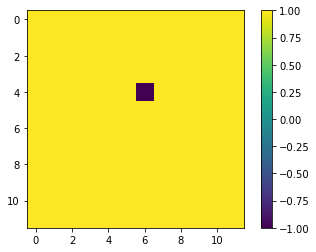

In [250]:
K_B = 1;

def aceptar_cambio(m, T, K=1, filtro=filtro1):
    temp = cambiar_spin(m, K=K, filtro=filtro)
    t0 = np.min([np.exp(-temp[1]/(K_B*T)),1])
    t1 = np.random.uniform(0,1)
    if t1 > t0: 
        m = temp[0] 
    else:
        pass 
    return m

p = aceptar_cambio(red, 1.5, K=1, filtro=filtro1)
plt.imshow(p); plt.colorbar(); plt.show()

In [265]:
def evolucion(m, T, vueltas, K=1, filtro=filtro1):
    config, energias, mag = [], [], []
    for i in range(vueltas):
        config.append(m)
        energias.append(energia_p(m, filtro=filtro))
        mag.append(mag_p(m))
        m = aceptar_cambio(m, T, K=1, filtro=filtro)
    return config, energias, mag

config, energias, mag = evolucion(red, 1.5, 500, filtro=filtro2)
config_a1, energias_a1, mag_a1 = evolucion(red_a, 1.5, 500, filtro=filtro2)
config_a2, energias_a2, mag_a2 = evolucion(red_a, 1.5, 500, filtro=filtro2)
config_a3, energias_a3, mag_a3 = evolucion(red_a, 1.5, 500, filtro=filtro2)

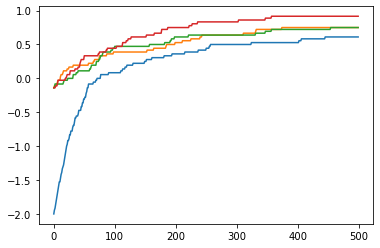

In [267]:
plt.plot(range(len(energias)), energias)
plt.plot(range(len(energias)), energias_a1)
plt.plot(range(len(energias)), energias_a2)
plt.plot(range(len(energias)), energias_a3)
plt.show()

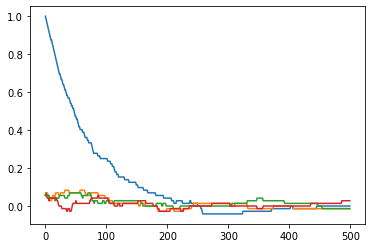

In [266]:
plt.plot(range(len(energias)), mag)
plt.plot(range(len(energias)), mag_a1)
plt.plot(range(len(energias)), mag_a2)
plt.plot(range(len(energias)), mag_a3)
plt.show()

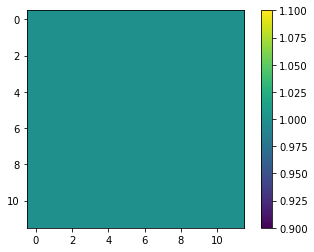

In [257]:
plt.imshow(config[-0]); plt.colorbar(); plt.show()

### Método de Newton-Rapson

In [123]:
def newton(f,df,a,b,epsilon):
    dx=2*epsilon
    contador = 0
    x=0.5*(a+b)
    while dx> epsilon and contador<1000:
        x1=x-f(x)/df(x)
        dx=abs(x-x1)
        x=x1
        contador=contador+1
    return [x,contador]

\begin{equation}\label{eq:1}
    2\tanh^2\left(\frac{2J}{K_BT_c}\right)=1
\end{equation}


Entonces proponemos la función $f(T)$ tal que
\begin{equation}
f(T)=2\tanh^2\left(\frac{2J}{K_BT}\right)-1
\end{equation}

\begin{equation}
\Rightarrow \frac{df(T)}{dT}=\frac{d}{dT}\left(2\tanh^2\left(\frac{2J}{K_BT}\right)-1\right)=-\frac{8J}{T^2K_B}\tanh \left(\frac{2 J}{K_B T}\right)   \text{sech}^2\left(\frac{2 J}{K_B T}\right)
\end{equation}

In [124]:
J = 0.5; K_B=1;
def f(T):
    return 2*(np.tanh(2*J/(K_B*T)))**2-1

def df(T):
    t1 = -8/((T**2)*K_B)
    t2 = np.tanh(2*J/(K_B*T))
    t3 = 1/(np.cosh(2*J/(K_B*T))**2)       
    return t1*t2*t3

Tc = newton(f,df,1,1.5,1e-5)[0]
Tc

1.134598744438543

$$T_c=1.134598744438543$$

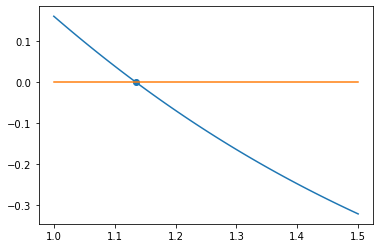

In [125]:
T = np.linspace(1,1.5);
plt.plot(T,f(T))
plt.plot(T,np.zeros(50))
plt.scatter(Tc,f(Tc))
plt.show()